In [1]:
import os
import copy
import glob
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import imageio
from tqdm import tqdm
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"


# Import your local modules
# Ensure conditional_unet_depth.py and diffusion.py are in the same folder
from conditional_unet_depth import ConditionalUNetDepth
from diffusion import GaussianDiffusion, DiffusionConfig

# --- Configuration ---
CONFIG = {
    "img_size": 128,        # Resize all images to this (e.g., 128 or 256)
    "batch_size": 16,       # Adjust based on VRAM (8GB should handle 16-32 at 128x128)
    "lr": 1e-4,
    "epochs": 25,
    "timesteps": 1000,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    # Paths are relative to the term_project folder
    "synthetic_root": "../dataset/synthetic_dataset",
    # Use both d415_dataset and d435_dataset under real-val
    "real_val_root": "../dataset/real-val",
    "ema_decay": 0.995,  # How slow the EMA model updates
    "loss_type": "l2"  # l1 sharper or l2 standard
}

print(f"Running on device: {CONFIG['device']}")


Running on device: cuda


In [2]:
# --- EMA (Exponential Moving Average) Helper Class ---

class EMA:
    """Maintains a slowly updating copy of the model weights."""
    def __init__(self, model, beta=0.995):
        self.beta = beta
        self.ema_model = copy.deepcopy(model)
        self.ema_model.eval()
        # Freeze EMA parameters (they are updated manually)
        for param in self.ema_model.parameters():
            param.requires_grad = False

    def update(self, model):
        """Update EMA parameters: new_ema = beta * old_ema + (1-beta) * current"""
        with torch.no_grad():
            for current_params, ema_params in zip(model.parameters(), self.ema_model.parameters()):
                ema_params.data = self.beta * ema_params.data + (1 - self.beta) * current_params.data

    def __call__(self, *args, **kwargs):
        return self.ema_model(*args, **kwargs)


In [3]:

# --- Dataset Class ---

class ClearGraspDataset(Dataset):
    def __init__(self, root_dir, split="synthetic", img_size=128, max_depth=3.0):
        """
        Args:
            root_dir: Path to dataset folder.
            split: "synthetic" (training) or "real" (validation/test).
            img_size: Target size for resizing (square).
            max_depth: Maximum depth value (in meters) for normalization.
                       ClearGrasp usually clips around 3m-10m. 3.0m is a safe focus for manipulation.
        """
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.max_depth = max_depth

        self.samples = []

        if self.split == "synthetic":
            # Synthetic structure: Class/depth-imgs-rectified/*.exr
            # We need to find matching RGB and Mask files.
            # Assumes structure: class_name/depth-imgs-rectified/000.exr
            #                    class_name/rgb-imgs/000.jpg
            #                    class_name/segmentation-masks/000.png (or similar)

            # Walk through all class folders
            for class_folder in glob.glob(os.path.join(root_dir, "*")):
                if not os.path.isdir(class_folder): continue

                depth_folder = os.path.join(class_folder, "depth-imgs-rectified")
                rgb_folder = os.path.join(class_folder, "rgb-imgs")
                # Note: Check the exact name of your mask folder in the synthetic dataset!
                # Often it is 'segmentation-masks' or similar.
                mask_folder = os.path.join(class_folder, "segmentation-masks")

                if not os.path.exists(depth_folder): continue

                depth_files = sorted(glob.glob(os.path.join(depth_folder, "*.exr")))

                for df in depth_files:
                    basename = os.path.basename(df).split("-")[0] # e.g. "000000000"

                    # Construct paths for RGB and Mask
                    # Adjust extensions/naming patterns based on your actual file listing!
                    rgb_path = os.path.join(rgb_folder, f"{basename}-rgb.jpg")
                    mask_path = os.path.join(mask_folder, f"{basename}-segmentation-mask.png")

                    if os.path.exists(rgb_path) and os.path.exists(mask_path):
                        self.samples.append({
                            "depth": df,
                            "rgb": rgb_path,
                            "mask": mask_path
                        })

        elif self.split == "real":
            # Real Val/Test structure (flat folder):
            # 000-opaque-depth-img.exr (Target)
            # 000-transparent-depth-img.exr (Input Bad Depth)
            # 000-transparent-rgb-img.jpg (Input RGB)

            # We iterate over opaque depth (ground truth targets)
            target_files = sorted(glob.glob(os.path.join(root_dir, "**", "*-opaque-depth-img.exr"), recursive=True))

            for tf in target_files:
                # e.g. .../000000000-opaque-depth-img.exr
                prefix = tf.split("-opaque")[0] # .../000000000

                input_depth_path = f"{prefix}-transparent-depth-img.exr"
                input_rgb_path = f"{prefix}-transparent-rgb-img.jpg"

                if os.path.exists(input_depth_path) and os.path.exists(input_rgb_path):
                    self.samples.append({
                        "target_depth": tf,
                        "input_depth": input_depth_path,
                        "rgb": input_rgb_path
                    })

        print(f"Found {len(self.samples)} samples for split: {split}")

    def load_exr(self, path):
        # Load EXR file using OpenCV
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise RuntimeError(f"Failed to load EXR: {path}")
        # Handle potential multi-channel EXR (take first channel if 3)
        if len(img.shape) == 3:
            img = img[:, :, 0]
        img = img.astype(np.float32)
        # Replace NaN / Inf with 0 (background)
        img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
        return img

    def process_image(self, img, image_type="rgb"):
        """
        image_type: 'rgb', 'depth', or 'mask'
        """
        # 1. Center Crop
        h, w = img.shape[:2]
        min_dim = min(h, w)
        top, left = (h - min_dim) // 2, (w - min_dim) // 2
        img = img[top:top+min_dim, left:left+min_dim]

        # 2. Resize
        interp = cv2.INTER_LINEAR if image_type == "rgb" else cv2.INTER_NEAREST
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=interp)

        # 3. To Tensor & Normalize
        if image_type == "rgb":
            # RGB: [0, 255] -> [-1, 1]
            img = torch.from_numpy(img).permute(2, 0, 1).float()
            img = (img / 127.5) - 1.0

        elif image_type == "mask":
            # Mask: [0, 255] -> [0, 1]
            img = torch.from_numpy(img).unsqueeze(0).float()
            img = img / 255.0  # Masks are always 0-255

        elif image_type == "depth":
            # Depth: [0, max_depth] -> [-1, 1]
            img = torch.from_numpy(img).unsqueeze(0).float()
            # CRITICAL FIX: Do NOT check img.max() here. Always normalize depth.
            img = torch.clamp(img, 0, self.max_depth)
            img = img / self.max_depth # Now [0, 1]
            img = (img * 2.0) - 1.0    # Now [-1, 1]

        return img

    def apply_realistic_corruption(self, depth, mask):
        """
        Apply realistic sensor-like corruption to depth inside transparent-object regions.

        depth: (1, H, W) normalized tensor in [-1, 1]
        mask : (1, H, W) tensor in [0, 1], where > 0 indicates object.
        """
        corrupted = depth.clone()

        # Object region (transparent object)
        object_indices = (mask > 0.0)

        if not object_indices.any():
            return corrupted

        # 1. Dropout: some pixels become completely "missing" (-1.0 after normalization)
        dropout_prob = 0.6
        dropout_mask = (torch.rand_like(depth) < dropout_prob) & object_indices
        corrupted[dropout_mask] = -1.0

        # 2. Noise: remaining object pixels get strong depth noise
        noise_indices = object_indices & (~dropout_mask)

        if noise_indices.any():
            # Strong Gaussian noise in [-1, 1] space
            noise = torch.randn_like(depth) * 0.5
            corrupted[noise_indices] = corrupted[noise_indices] + noise[noise_indices]
            # Clip back to valid range
            corrupted = torch.clamp(corrupted, -1.0, 1.0)

        return corrupted

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # RGB
        rgb = cv2.imread(sample["rgb"])
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        rgb_tensor = self.process_image(rgb, image_type="rgb")

        if self.split == "synthetic":
            target_depth_raw = self.load_exr(sample["depth"])
            mask = cv2.imread(sample["mask"], cv2.IMREAD_GRAYSCALE)

            # Ensure mask matches depth size before processing
            if mask.shape != target_depth_raw.shape:
                mask = cv2.resize(mask, (target_depth_raw.shape[1], target_depth_raw.shape[0]), interpolation=cv2.INTER_NEAREST)

            # Explicitly specify types now!
            target_depth_tensor = self.process_image(target_depth_raw, image_type="depth")
            mask_tensor = self.process_image(mask, image_type="mask")

            input_depth_tensor = self.apply_realistic_corruption(target_depth_tensor, mask_tensor)

        else:
            # Real data
            target_depth_raw = self.load_exr(sample["target_depth"])
            input_depth_raw = self.load_exr(sample["input_depth"])

            target_depth_tensor = self.process_image(target_depth_raw, image_type="depth")
            input_depth_tensor = self.process_image(input_depth_raw, image_type="depth")

        conditioning = torch.cat([rgb_tensor, input_depth_tensor], dim=0)

        return {
            "pixel_values": target_depth_tensor,
            "conditioning": conditioning
        }

    def __len__(self):
        return len(self.samples)

Found 940 samples for split: synthetic
RGBD Cond Shape: torch.Size([4, 128, 128])
Target Depth Shape: torch.Size([1, 128, 128])
Depth Min: -0.7567
Depth Max: -0.2188


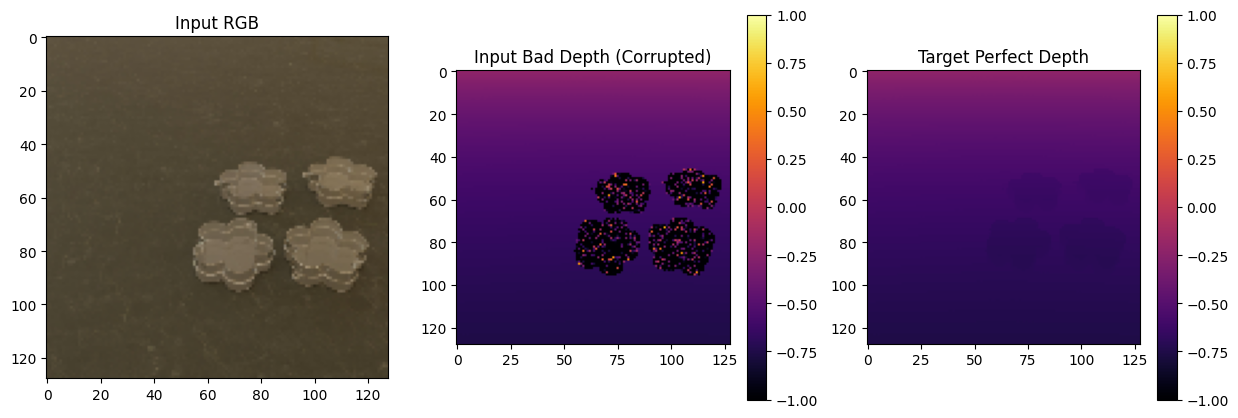

In [4]:

# --- Sanity Check Block ---
if __name__ == "__main__":
    try:
        # Initialize dataset
        ds = ClearGraspDataset(CONFIG['synthetic_root'], split="synthetic", img_size=128)

        if len(ds) > 0:
            item = ds[0] # Check index 0 or 5000

            # Print Stats
            print("RGBD Cond Shape:", item["conditioning"].shape)
            print("Target Depth Shape:", item["pixel_values"].shape)
            print(f"Depth Min: {item['pixel_values'].min().item():.4f}")
            print(f"Depth Max: {item['pixel_values'].max().item():.4f}")
            # Expected: Min close to -1.0 (0m), Max close to 1.0 (3m) or smaller if object is close

            # Visualization
            cond_rgb = item["conditioning"][:3].permute(1, 2, 0).cpu().numpy()
            cond_rgb = (cond_rgb + 1) / 2.0

            bad_depth = item["conditioning"][3].cpu().numpy()
            good_depth = item["pixel_values"][0].cpu().numpy()

            fig, ax = plt.subplots(1, 3, figsize=(15, 5))

            ax[0].imshow(cond_rgb)
            ax[0].set_title("Input RGB")

            # Enforce vmin=-1, vmax=1 to see the true normalized range
            im1 = ax[1].imshow(bad_depth, cmap='inferno', vmin=-1, vmax=1)
            ax[1].set_title("Input Bad Depth (Corrupted)")
            plt.colorbar(im1, ax=ax[1])

            im2 = ax[2].imshow(good_depth, cmap='inferno', vmin=-1, vmax=1)
            ax[2].set_title("Target Perfect Depth")
            plt.colorbar(im2, ax=ax[2])

            plt.show()
    except Exception as e:
        print(f"Error: {e}")

Found 940 samples for split: synthetic


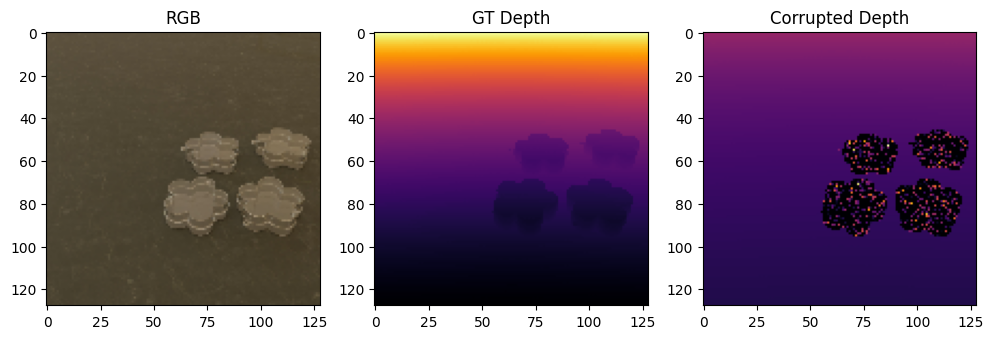

In [5]:
ds = ClearGraspDataset(CONFIG['synthetic_root'], split="synthetic", img_size=CONFIG['img_size'])
item = ds[0]
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(((item['conditioning'][:3].permute(1,2,0)+1)/2).cpu().numpy()); plt.title("RGB")
plt.subplot(1,3,2); plt.imshow(((item['pixel_values'][0]+1)/2).cpu().numpy(), cmap='inferno'); plt.title("GT Depth")
plt.subplot(1,3,3); plt.imshow(((item['conditioning'][3]+1)/2).cpu().numpy(), cmap='inferno'); plt.title("Corrupted Depth")
plt.show()


In [6]:
def train():
    print(f"Starting Training on {CONFIG['device']}...")

    # 1. Models
    model = ConditionalUNetDepth().to(CONFIG["device"])

    # Initialize EMA model (copy of initial weights)
    ema = EMA(model, beta=CONFIG["ema_decay"])
    diffusion = GaussianDiffusion(model=model, config=DiffusionConfig(timesteps=CONFIG["timesteps"])).to(CONFIG["device"])

    # 2. Setup Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"])

    # 3. Setup Dataloader
    # We focus on synthetic data for training as per plan
    train_ds = ClearGraspDataset(CONFIG['synthetic_root'], split="synthetic", img_size=CONFIG['img_size'])
    train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, pin_memory=True)

    # Validation set (Real data) for periodic sampling
    val_ds = ClearGraspDataset(CONFIG['real_val_root'], split="real", img_size=CONFIG['img_size'])
    # Fixed batch for consistent visualization
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=True)
    val_batch = next(iter(val_loader))
    val_cond = val_batch["conditioning"].to(CONFIG["device"])
    val_gt = val_batch["pixel_values"].to(CONFIG["device"])

    print(f"Starting training on {len(train_ds)} samples...")

    # 4. Training Loop
    for epoch in range(CONFIG["epochs"]):
        model.train()
        epoch_loss = 0

        # Wrap dataloader with tqdm for per-epoch progress bar
        for step, batch in enumerate(tqdm(train_dl, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}", leave=False)):
            optimizer.zero_grad()

            # Unpack
            x_start = batch["pixel_values"].to(CONFIG["device"])
            cond = batch["conditioning"].to(CONFIG["device"])
            b = x_start.shape[0]

            # Noise
            t = torch.randint(0, CONFIG["timesteps"], (b,), device=CONFIG["device"]).long()
            noise = torch.randn_like(x_start)

            # Forward Diffusion (q_sample)
            x_noisy, _ = diffusion.q_sample(x_start=x_start, t=t, noise=noise)

            # Predict Noise
            predicted_noise = model(x_noisy, cond, t)

            # Loss Calculation
            if CONFIG["loss_type"] == 'l1':
                loss = F.l1_loss(predicted_noise, noise)
            else:
                loss = F.mse_loss(predicted_noise, noise)

            # Backprop
            loss.backward()
            optimizer.step()

            # Update EMA
            ema.update(model)

            epoch_loss += loss.item()

            if step % 100 == 0:
                tqdm.write(f"Ep {epoch} | Step {step} | Loss: {loss.item():.4f}")

        print(f"--- Epoch {epoch} Avg Loss: {epoch_loss / len(train_dl):.4f} ---")

        # 5. Periodic Sampling (Validation)
        if epoch % 5 == 0: # Sample every 5 epochs
            print("Sampling validation images...")

            # We manually run the sample loop using the EMA model inside diffusion
            # Temporarily swap the model in diffusion wrapper to use EMA for sampling
            # (Or just pass the model to a sample function if refactored)

            # Quick hack to sample using EMA weights:
            original_model_weights = model.state_dict()
            model.load_state_dict(ema.ema_model.state_dict())

            model.eval()
            with torch.no_grad():
                # Generate depth from the real-world "bad" depth
                sampled_depth = diffusion.sample(cond=val_cond, shape=(4, 1, CONFIG['img_size'], CONFIG['img_size']))

            # Restore original weights for training
            model.load_state_dict(original_model_weights)
            model.train()

            # Visualize first sample in batch
            # RGB
            rgb_viz = (val_cond[0, :3].permute(1, 2, 0).cpu().numpy() + 1) / 2
            # Bad Input Depth
            input_depth_viz = (val_cond[0, 3].cpu().numpy() + 1) / 2
            # Generated Depth
            gen_depth_viz = (sampled_depth[0, 0].cpu().numpy() + 1) / 2
            # Ground Truth
            gt_depth_viz = (val_gt[0, 0].cpu().numpy() + 1) / 2

            fig, ax = plt.subplots(1, 4, figsize=(20, 5))
            ax[0].imshow(np.clip(rgb_viz, 0, 1))
            ax[0].set_title("Input RGB")
            ax[1].imshow(input_depth_viz, cmap='inferno')
            ax[1].set_title("Input Bad Depth")
            ax[2].imshow(gen_depth_viz, cmap='inferno')
            ax[2].set_title(f"Generated (Epoch {epoch})")
            ax[3].imshow(gt_depth_viz, cmap='inferno')
            ax[3].set_title("Ground Truth")
            plt.show()

            # Save Checkpoint
            torch.save(model.state_dict(), f"model_epoch_{epoch}.pt")

Starting Training on cuda...
Found 940 samples for split: synthetic
Found 263 samples for split: real
Starting training on 940 samples...
Found 940 samples for split: synthetic
Found 263 samples for split: real
Starting training on 940 samples...


Epoch 1/25:   2%|▏         | 1/59 [00:01<01:19,  1.36s/it]

Ep 0 | Step 0 | Loss: 1.4010


--- Epoch 0 Avg Loss: 0.1712 ---
Sampling validation images...


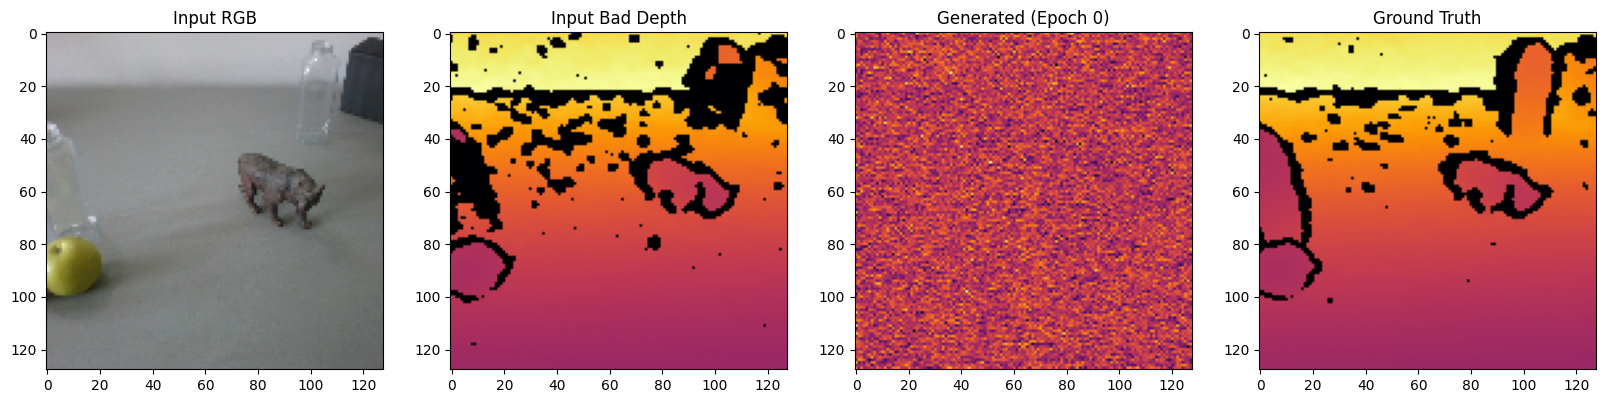

Epoch 2/25:   2%|▏         | 1/59 [00:01<00:59,  1.03s/it]

Ep 1 | Step 0 | Loss: 0.5435


--- Epoch 1 Avg Loss: 0.1023 ---


Epoch 3/25:   2%|▏         | 1/59 [00:01<00:58,  1.01s/it]

Ep 2 | Step 0 | Loss: 0.0334


...

Ep 4 | Step 0 | Loss: 0.0166


--- Epoch 4 Avg Loss: 0.0179 ---


Epoch 6/25:   2%|▏         | 1/59 [00:01<01:10,  1.22s/it]

Ep 5 | Step 0 | Loss: 0.0110


--- Epoch 5 Avg Loss: 0.0170 ---
Sampling validation images...


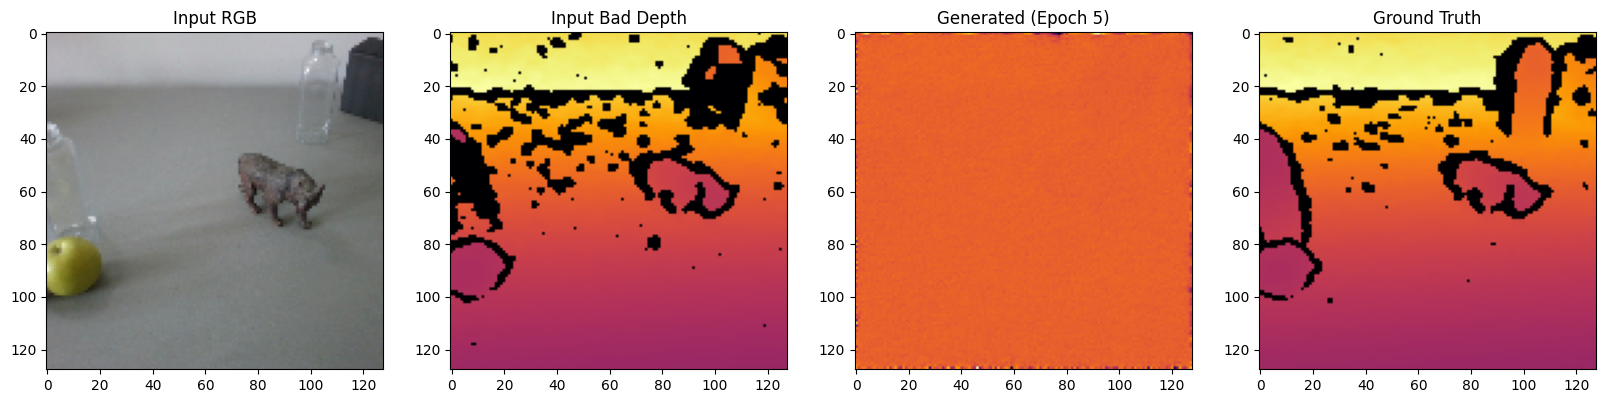

Epoch 7/25:   2%|▏         | 1/59 [00:01<01:04,  1.12s/it]

Ep 6 | Step 0 | Loss: 0.0229


--- Epoch 6 Avg Loss: 0.0224 ---


Epoch 8/25:   2%|▏         | 1/59 [00:01<01:02,  1.07s/it]

Ep 7 | Step 0 | Loss: 0.0164


...

Ep 9 | Step 0 | Loss: 0.0059


--- Epoch 9 Avg Loss: 0.0098 ---


Epoch 11/25:   2%|▏         | 1/59 [00:01<01:06,  1.15s/it]

Ep 10 | Step 0 | Loss: 0.0079


--- Epoch 10 Avg Loss: 0.0079 ---
Sampling validation images...


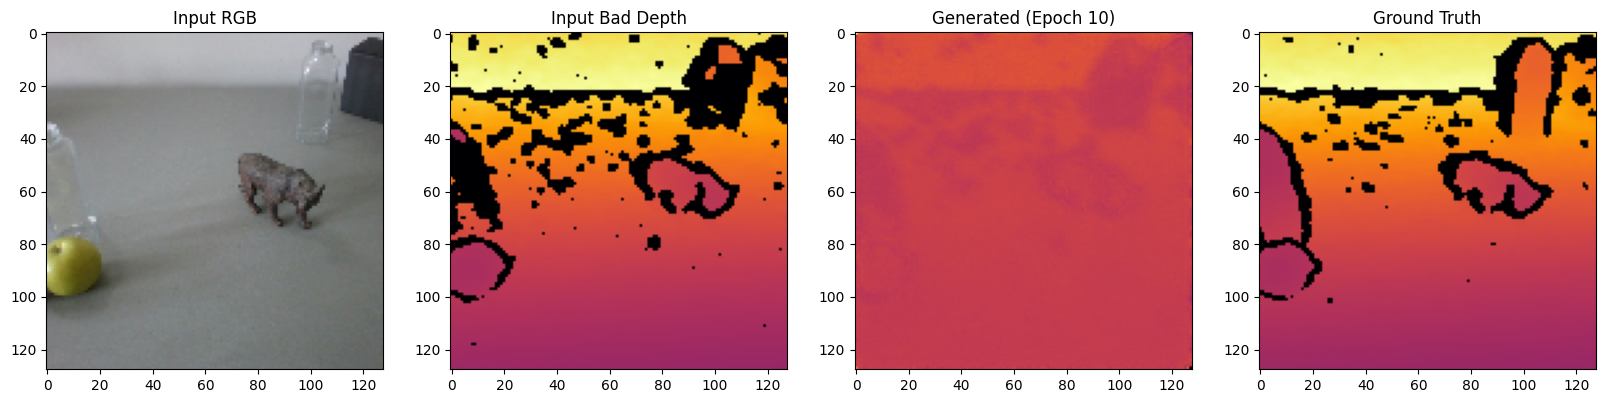

Epoch 12/25:   2%|▏         | 1/59 [00:00<00:54,  1.07it/s]

Ep 11 | Step 0 | Loss: 0.0113


--- Epoch 11 Avg Loss: 0.0086 ---


Epoch 13/25:   2%|▏         | 1/59 [00:01<01:00,  1.04s/it]

Ep 12 | Step 0 | Loss: 0.0071


...

Ep 14 | Step 0 | Loss: 0.0065


--- Epoch 14 Avg Loss: 0.0059 ---


Epoch 16/25:   2%|▏         | 1/59 [00:01<01:12,  1.26s/it]

Ep 15 | Step 0 | Loss: 0.0028


--- Epoch 15 Avg Loss: 0.0067 ---
Sampling validation images...


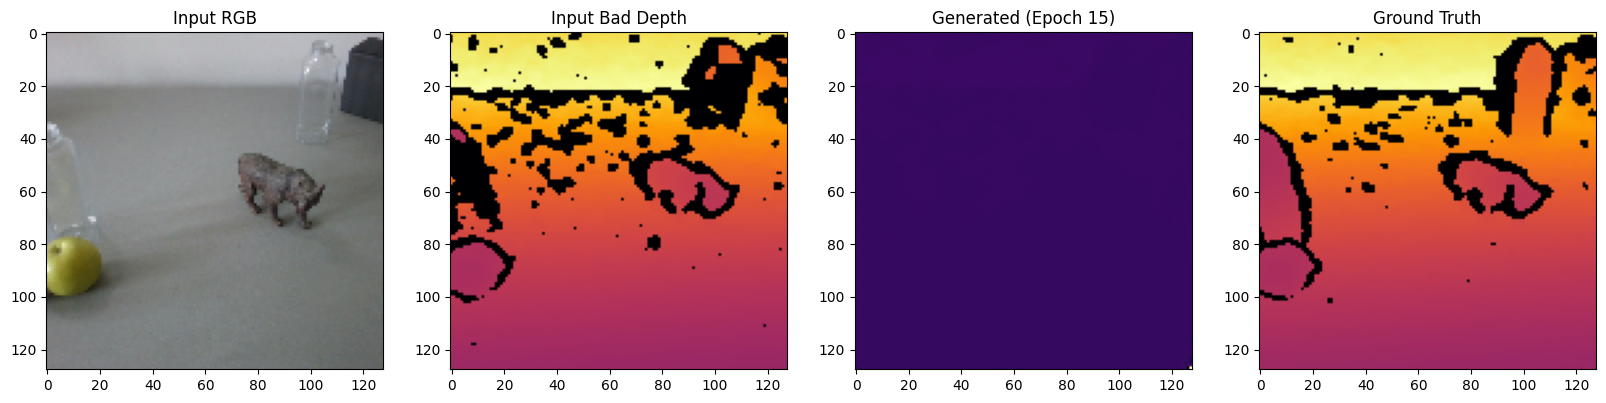

Epoch 17/25:   2%|▏         | 1/59 [00:01<01:05,  1.13s/it]

Ep 16 | Step 0 | Loss: 0.0036


--- Epoch 16 Avg Loss: 0.0078 ---


Epoch 18/25:   2%|▏         | 1/59 [00:01<01:10,  1.21s/it]

Ep 17 | Step 0 | Loss: 0.0035


...

Ep 19 | Step 0 | Loss: 0.0116


--- Epoch 19 Avg Loss: 0.0059 ---


Epoch 21/25:   2%|▏         | 1/59 [00:01<01:09,  1.19s/it]

Ep 20 | Step 0 | Loss: 0.0037


--- Epoch 20 Avg Loss: 0.0042 ---
Sampling validation images...


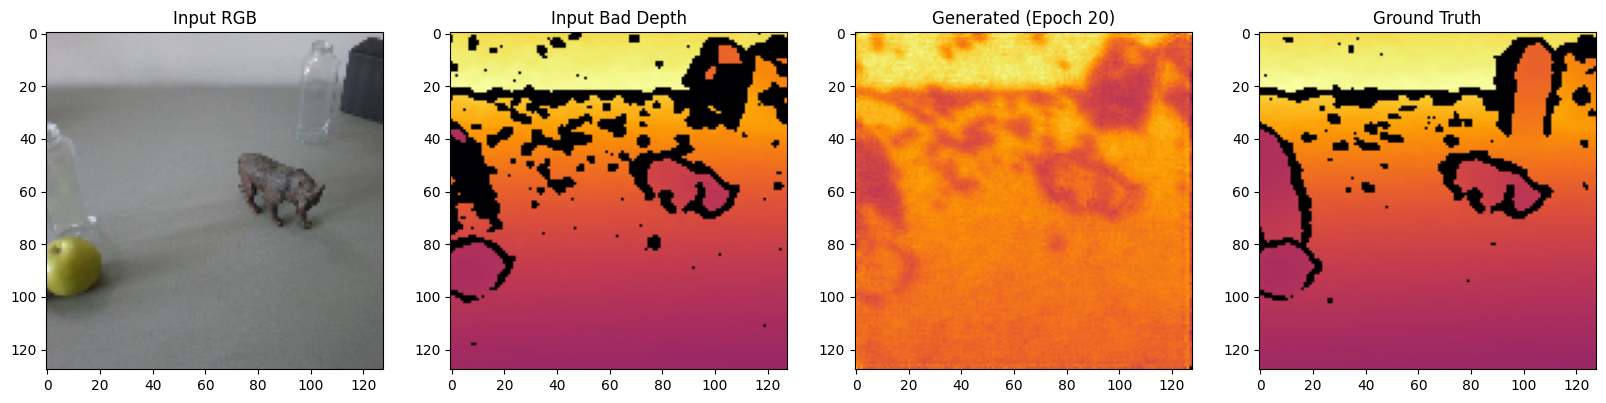

Epoch 22/25:   2%|▏         | 1/59 [00:01<01:02,  1.08s/it]

Ep 21 | Step 0 | Loss: 0.0081


--- Epoch 21 Avg Loss: 0.0065 ---


Epoch 23/25:   2%|▏         | 1/59 [00:01<00:59,  1.03s/it]

Ep 22 | Step 0 | Loss: 0.0043


...

Ep 23 | Step 0 | Loss: 0.0022


--- Epoch 23 Avg Loss: 0.0041 ---


Epoch 25/25:   2%|▏         | 1/59 [00:01<01:10,  1.22s/it]

Ep 24 | Step 0 | Loss: 0.0251


--- Epoch 24 Avg Loss: 0.0066 ---


In [7]:
if __name__ == "__main__":
    train()